In [ ]:
import numpy as np

# ---------------------------
# CONFIGURACIÓN DEL CIRCUITO
# ---------------------------

# Centro del arco
cx, cy = -300, -285
R = 170

# Puntos de inicio/fin en tu coordenada original
entry  = np.array([-354.66401, -445.97157])
exit_  = np.array([-138.12432, -336.92555])

# Número de líneas que quieres analizar
N = 300


# ---------------------------------------
# FUNCIONES DE GEOMETRÍA
# ---------------------------------------

def length(p1, p2):
    """Distancia entre dos puntos."""
    return np.linalg.norm(p2 - p1)

def angle_of_point(p, cx, cy):
    """Ángulo polar del punto relativo al centro."""
    x, y = p[0] - cx, p[1] - cy
    return np.arctan2(y, x)

def point_on_circle(theta, cx, cy, R):
    """Punto en el círculo dado un ángulo."""
    return np.array([cx + R*np.cos(theta),
                     cy + R*np.sin(theta)])


# ---------------------------------------
# GENERACIÓN DE LÍNEAS DE CARRERA
# ---------------------------------------

def racing_line(theta_entry, theta_exit):
    """
    Crea la línea:
    - recta desde entry → punto de tangencia 1
    - arco del círculo entre theta_entry y theta_exit
    - recta hasta exit
    """

    p1 = point_on_circle(theta_entry, cx, cy, R)
    p2 = point_on_circle(theta_exit, cx, cy, R)

    # Longitud de cada segmento
    L1 = length(entry, p1)
    Larc = R * abs(theta_exit - theta_entry)
    L2 = length(p2, exit_)

    return L1 + Larc + L2


# ---------------------------------------
# OPTIMIZACIÓN BÁSICA
# ---------------------------------------

θ_entry_real = angle_of_point(entry, cx, cy)
θ_exit_real  = angle_of_point(exit_, cx, cy)

# Probamos variaciones de ±20º
delta = np.linspace(-0.35, 0.35, N)

results = []

for d1 in delta:
    for d2 in delta:
        L = racing_line(θ_entry_real + d1, θ_exit_real + d2)
        results.append((L, d1, d2))

best = min(results, key=lambda x: x[0])

print("Mejor longitud:", best[0])
print("Desviación entrada:", best[1])
print("Desviación salida:", best[2])

Mejor longitud: 269.31279092904487
Desviación entrada: 0.35
Desviación salida: -0.35


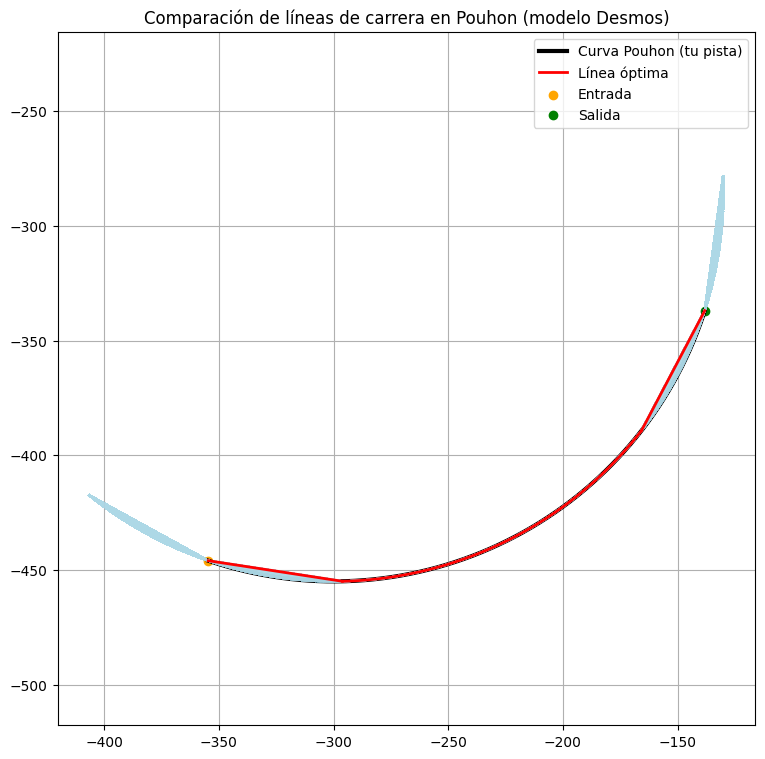

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# CONFIGURACIÓN DEL ARCO (Pouhon)
# ---------------------------

cx, cy = -300, -285   # centro del arco
R = 170               # radio

entry  = np.array([-354.66401, -445.97157])
exit_  = np.array([-138.12432, -336.92555])

# ---------------------------
# FUNCIONES
# ---------------------------

def length(p1, p2):
    return np.linalg.norm(p2 - p1)

def angle_of_point(p, cx, cy):
    x, y = p[0] - cx, p[1] - cy
    return np.arctan2(y, x)

def point_on_circle(theta, cx, cy, R):
    return np.array([cx + R*np.cos(theta), 
                     cy + R*np.sin(theta)])

def racing_line_points(theta_entry, theta_exit, resolution=200):
    p1 = point_on_circle(theta_entry, cx, cy, R)
    p2 = point_on_circle(theta_exit, cx, cy, R)

    line1 = np.linspace(entry, p1, 50)
    thetas = np.linspace(theta_entry, theta_exit, resolution)
    arc = np.array([point_on_circle(t, cx, cy, R) for t in thetas])
    line2 = np.linspace(p2, exit_, 50)

    return line1, arc, line2


# ---------------------------
# OPTIMIZACIÓN
# ---------------------------

θ_entry_real = angle_of_point(entry, cx, cy)
θ_exit_real  = angle_of_point(exit_, cx, cy)

def racing_line_length(te, tx):
    p1 = point_on_circle(te, cx, cy, R)
    p2 = point_on_circle(tx, cx, cy, R)
    return length(entry, p1) + R*abs(tx - te) + length(p2, exit_)


# variaciones ±20°
N = 100
delta = np.linspace(-0.35, 0.35, N)

results = []
all_lines = []

for d1 in delta:
    for d2 in delta:
        te = θ_entry_real + d1
        tx = θ_exit_real + d2

        L = racing_line_length(te, tx)
        results.append((L, te, tx))

        # guardamos la curva completa para graficarla luego
        all_lines.append(racing_line_points(te, tx))

# mejor línea
best = min(results, key=lambda x: x[0])
best_te, best_tx = best[1], best[2]


# ---------------------------
# GRAFICAR
# ---------------------------

plt.figure(figsize=[9,9])

# 1. PISTA = SOLO LA PARTE ENTRE ENTRY Y EXIT
theta_track = np.linspace(θ_entry_real, θ_exit_real, 400)
track = np.array([point_on_circle(t, cx, cy, R) for t in theta_track])
plt.plot(track[:,0], track[:,1], color='black', linewidth=3, label="Curva Pouhon (tu pista)")

# 2. TODAS LAS LÍNEAS DE CARRERA
for (line1, arc, line2) in all_lines:
    plt.plot(line1[:,0], line1[:,1], color='lightblue', alpha=0.15)
    plt.plot(arc[:,0], arc[:,1], color='lightblue', alpha=0.15)
    plt.plot(line2[:,0], line2[:,1], color='lightblue', alpha=0.15)

# 3. LA LÍNEA DE CARRERA ÓPTIMA
line1, arc, line2 = racing_line_points(best_te, best_tx)
plt.plot(line1[:,0], line1[:,1], color='red', linewidth=2, label="Línea óptima")
plt.plot(arc[:,0], arc[:,1], color='red', linewidth=2)
plt.plot(line2[:,0], line2[:,1], color='red', linewidth=2)

# puntos clave
plt.scatter(*entry, color='orange', label="Entrada")
plt.scatter(*exit_, color='green', label="Salida")

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Comparación de líneas de carrera en Pouhon (modelo Desmos)")
plt.show()


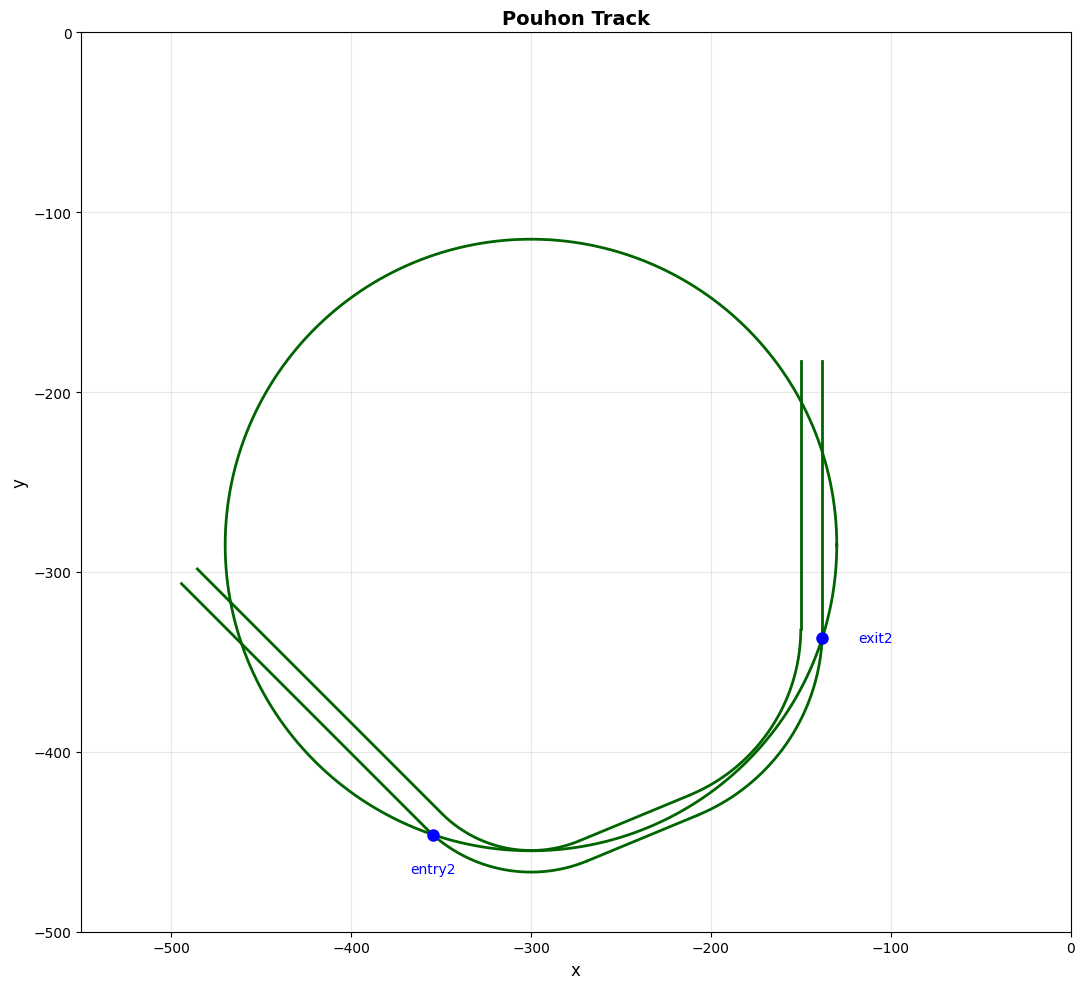

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Define the curves and lines from your Desmos graph

# Line 1: y = -x - 800.8 {y < x + 530 - 341.5} {y > x + 300 - 384.85}
x1 = np.linspace(-600, 200, 1000)
y1 = -x1 - 800.8
mask1 = (y1 < x1 + 188.5) & (y1 > x1 + 300 - 384.85)
ax.plot(x1[mask1], y1[mask1], 'darkgreen', linewidth=2)

# Line 2: y = -x - 800.8 + 12*sqrt(2) {y < x + 188.5} {y > x - 84.85}
y2 = -x1 - 800.8 + 12*np.sqrt(2)
mask2 = (y2 < x1 + 188.5) & (y2 > x1 - 84.85)
ax.plot(x1[mask2], y2[mask2], 'darkgreen', linewidth=2)

# Circle 1: (x + 300)^2 + (y + 384.85)^2 = 70^2 
# {y < x + 300 - 384.85} {y + 384.85 < -1/tan(22.5) * (x + 300)}
theta = np.linspace(0, 2*np.pi, 1000)
x_circ1 = -300 + 70*np.cos(theta)
y_circ1 = -384.85 + 70*np.sin(theta)
mask_circ1 = (y_circ1 < x_circ1 + 300 - 384.85) & (y_circ1 + 384.85 < -1/np.tan(np.radians(22.5)) * (x_circ1 + 300))
ax.plot(x_circ1[mask_circ1], y_circ1[mask_circ1], 'darkgreen', linewidth=2)

# Circle 2: (x + 300)^2 + (y + 384.85)^2 = 82^2
# {y < x + 300 - 384.85} {y + 384.85 < -1/tan(22.5) * (x + 300)}
x_circ2 = -300 + 82*np.cos(theta)
y_circ2 = -384.85 + 82*np.sin(theta)
mask_circ2 = (y_circ2 < x_circ2 + 300 - 384.85) & (y_circ2 + 384.85 < -1/np.tan(np.radians(22.5)) * (x_circ2 + 300))
ax.plot(x_circ2[mask_circ2], y_circ2[mask_circ2], 'darkgreen', linewidth=2)

# Tangent line 1: y = tan(22.5)*x - 336.35 
# {y + 331.65 < -1/tan(22.5) * (x + 250)} {y + 384.85 > -1/tan(22.5) * (x + 300)}
x_tan = np.linspace(-600, 200, 1000)
y_tan1 = np.tan(np.radians(22.5))*x_tan - 336.35
mask_tan1 = (y_tan1 + 331.65 < -1/np.tan(np.radians(22.5)) * (x_tan + 250)) & \
            (y_tan1 + 384.85 > -1/np.tan(np.radians(22.5)) * (x_tan + 300))
ax.plot(x_tan[mask_tan1], y_tan1[mask_tan1], 'darkgreen', linewidth=2)

# Tangent line 2: y = tan(22.5)*x - 336.35 - 12/cos(22.5) 
# {y + 331.65 < -1/tan(22.5) * (x + 250)} {y + 384.85 > -1/tan(22.5) * (x + 300)}
y_tan2 = np.tan(np.radians(22.5))*x_tan - 336.35 - 12/np.cos(np.radians(22.5))
mask_tan2 = (y_tan2 + 331.65 < -1/np.tan(np.radians(22.5)) * (x_tan + 250)) & \
            (y_tan2 + 384.85 > -1/np.tan(np.radians(22.5)) * (x_tan + 300))
ax.plot(x_tan[mask_tan2], y_tan2[mask_tan2], 'darkgreen', linewidth=2)

# Circle 3: (x + 250)^2 + (y + 331.65)^2 = 100^2 
# {y < -331.65} {y + 331.65 > -1/tan(22.5) * (x + 250)}
x_circ3 = -250 + 100*np.cos(theta)
y_circ3 = -331.65 + 100*np.sin(theta)
mask_circ3 = (y_circ3 < -331.65) & (y_circ3 + 331.65 > -1/np.tan(np.radians(22.5)) * (x_circ3 + 250))
ax.plot(x_circ3[mask_circ3], y_circ3[mask_circ3], 'darkgreen', linewidth=2)

# Circle 4: (x + 250)^2 + (y + 331.65)^2 = 112^2 
# {y < -331.65} {y + 331.65 > -1/tan(22.5) * (x + 250)}
x_circ4 = -250 + 112*np.cos(theta)
y_circ4 = -331.65 + 112*np.sin(theta)
mask_circ4 = (y_circ4 < -331.65) & (y_circ4 + 331.65 > -1/np.tan(np.radians(22.5)) * (x_circ4 + 250))
ax.plot(x_circ4[mask_circ4], y_circ4[mask_circ4], 'darkgreen', linewidth=2)

# Vertical lines
y_vert = np.linspace(-500, -150, 1000)
# x = -150 {-182.62 > y > -331.65}
mask_v1 = (y_vert > -331.65) & (y_vert < -182.62)
ax.plot(np.full_like(y_vert[mask_v1], -150), y_vert[mask_v1], 'darkgreen', linewidth=2)
# x = -138 {-182.62 > y > -331.65}
mask_v2 = (y_vert > -331.65) & (y_vert < -182.62)
ax.plot(np.full_like(y_vert[mask_v2], -138), y_vert[mask_v2], 'darkgreen', linewidth=2)

# Large circle: (x + 300)^2 + (y + 285)^2 = 170^2
x_circ_large = -300 + 170*np.cos(theta)
y_circ_large = -285 + 170*np.sin(theta)
ax.plot(x_circ_large, y_circ_large, 'darkgreen', linewidth=2)

# Add labeled points
ax.plot(-354.66401, -445.97157, 'bo', markersize=8)
ax.text(-354.66401, -445.97157 - 15, 'entry2', fontsize=10, ha='center', va='top', color='blue')

ax.plot(-138.12432, -336.92555, 'bo', markersize=8)
ax.text(-138.12432 + 20, -336.92555, 'exit2', fontsize=10, ha='left', va='center', color='blue')

# Set equal aspect ratio and grid
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlim(-550, 0)
ax.set_ylim(-500, 0)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Pouhon Track', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

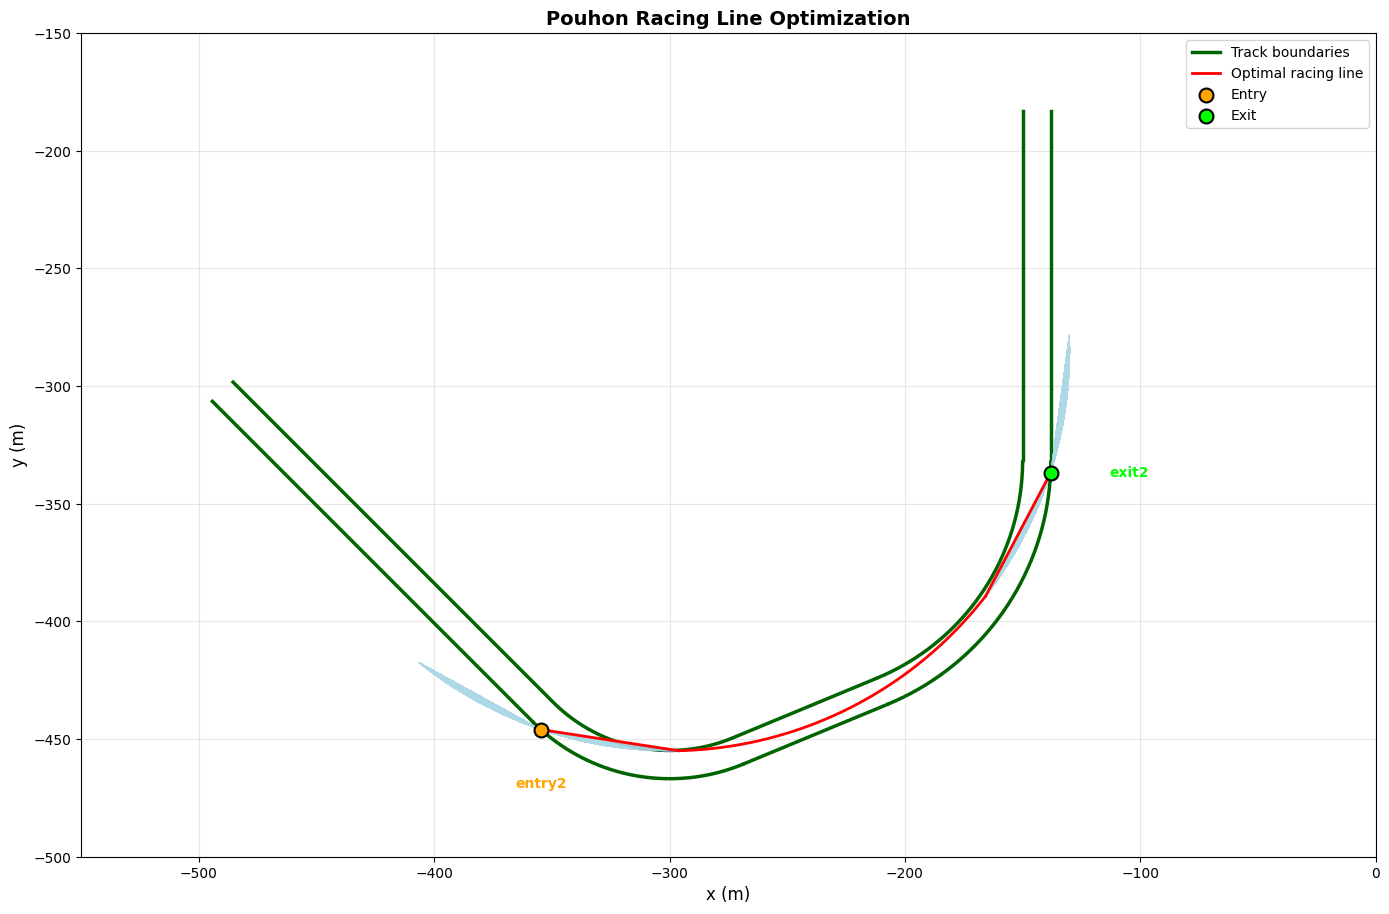


Optimal racing line:
  Entry angle: -88.70°
  Exit angle: -37.84°
  Total length: 269.31m


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# RACING LINE FUNCTIONS
# ---------------------------

cx, cy = -300, -285   # centro del arco
R = 170               # radio

entry  = np.array([-354.66401, -445.97157])
exit_  = np.array([-138.12432, -336.92555])

def length(p1, p2):
    return np.linalg.norm(p2 - p1)

def angle_of_point(p, cx, cy):
    x, y = p[0] - cx, p[1] - cy
    return np.arctan2(y, x)

def point_on_circle(theta, cx, cy, R):
    return np.array([cx + R*np.cos(theta), 
                     cy + R*np.sin(theta)])

def racing_line_points(theta_entry, theta_exit, resolution=200):
    p1 = point_on_circle(theta_entry, cx, cy, R)
    p2 = point_on_circle(theta_exit, cx, cy, R)

    line1 = np.linspace(entry, p1, 50)
    thetas = np.linspace(theta_entry, theta_exit, resolution)
    arc = np.array([point_on_circle(t, cx, cy, R) for t in thetas])
    line2 = np.linspace(p2, exit_, 50)

    return line1, arc, line2

def racing_line_length(te, tx):
    p1 = point_on_circle(te, cx, cy, R)
    p2 = point_on_circle(tx, cx, cy, R)
    return length(entry, p1) + R*abs(tx - te) + length(p2, exit_)

# ---------------------------
# OPTIMIZATION
# ---------------------------

θ_entry_real = angle_of_point(entry, cx, cy)
θ_exit_real  = angle_of_point(exit_, cx, cy)

N = 100
delta = np.linspace(-0.35, 0.35, N)

results = []
all_lines = []

for d1 in delta:
    for d2 in delta:
        te = θ_entry_real + d1
        tx = θ_exit_real + d2

        L = racing_line_length(te, tx)
        results.append((L, te, tx))
        all_lines.append(racing_line_points(te, tx))

best = min(results, key=lambda x: x[0])
best_te, best_tx = best[1], best[2]

# ---------------------------
# PLOTTING
# ---------------------------

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# TRACK BOUNDARIES FROM DESMOS

x1 = np.linspace(-600, 200, 1000)
y1 = -x1 - 800.8
mask1 = (y1 < x1 + 188.5) & (y1 > x1 + 300 - 384.85)
ax.plot(x1[mask1], y1[mask1], 'darkgreen', linewidth=2.5, label='Track boundaries')

y2 = -x1 - 800.8 + 12*np.sqrt(2)
mask2 = (y2 < x1 + 188.5) & (y2 > x1 - 84.85)
ax.plot(x1[mask2], y2[mask2], 'darkgreen', linewidth=2.5)

theta = np.linspace(0, 2*np.pi, 1000)
x_circ1 = -300 + 70*np.cos(theta)
y_circ1 = -384.85 + 70*np.sin(theta)
mask_circ1 = (y_circ1 < x_circ1 + 300 - 384.85) & (y_circ1 + 384.85 < -1/np.tan(np.radians(22.5)) * (x_circ1 + 300))
ax.plot(x_circ1[mask_circ1], y_circ1[mask_circ1], 'darkgreen', linewidth=2.5)

x_circ2 = -300 + 82*np.cos(theta)
y_circ2 = -384.85 + 82*np.sin(theta)
mask_circ2 = (y_circ2 < x_circ2 + 300 - 384.85) & (y_circ2 + 384.85 < -1/np.tan(np.radians(22.5)) * (x_circ2 + 300))
ax.plot(x_circ2[mask_circ2], y_circ2[mask_circ2], 'darkgreen', linewidth=2.5)

x_tan = np.linspace(-600, 200, 1000)
y_tan1 = np.tan(np.radians(22.5))*x_tan - 336.35
mask_tan1 = (y_tan1 + 331.65 < -1/np.tan(np.radians(22.5)) * (x_tan + 250)) & \
            (y_tan1 + 384.85 > -1/np.tan(np.radians(22.5)) * (x_tan + 300))
ax.plot(x_tan[mask_tan1], y_tan1[mask_tan1], 'darkgreen', linewidth=2.5)

y_tan2 = np.tan(np.radians(22.5))*x_tan - 336.35 - 12/np.cos(np.radians(22.5))
mask_tan2 = (y_tan2 + 331.65 < -1/np.tan(np.radians(22.5)) * (x_tan + 250)) & \
            (y_tan2 + 384.85 > -1/np.tan(np.radians(22.5)) * (x_tan + 300))
ax.plot(x_tan[mask_tan2], y_tan2[mask_tan2], 'darkgreen', linewidth=2.5)

x_circ3 = -250 + 100*np.cos(theta)
y_circ3 = -331.65 + 100*np.sin(theta)
mask_circ3 = (y_circ3 < -331.65) & (y_circ3 + 331.65 > -1/np.tan(np.radians(22.5)) * (x_circ3 + 250))
ax.plot(x_circ3[mask_circ3], y_circ3[mask_circ3], 'darkgreen', linewidth=2.5)

x_circ4 = -250 + 112*np.cos(theta)
y_circ4 = -331.65 + 112*np.sin(theta)
mask_circ4 = (y_circ4 < -331.65) & (y_circ4 + 331.65 > -1/np.tan(np.radians(22.5)) * (x_circ4 + 250))
ax.plot(x_circ4[mask_circ4], y_circ4[mask_circ4], 'darkgreen', linewidth=2.5)

y_vert = np.linspace(-500, -150, 1000)
mask_v1 = (y_vert > -331.65) & (y_vert < -182.62)
ax.plot(np.full_like(y_vert[mask_v1], -150), y_vert[mask_v1], 'darkgreen', linewidth=2.5)
mask_v2 = (y_vert > -331.65) & (y_vert < -182.62)
ax.plot(np.full_like(y_vert[mask_v2], -138), y_vert[mask_v2], 'darkgreen', linewidth=2.5)

# x_circ_large = -300 + 170*np.cos(theta)
# y_circ_large = -285 + 170*np.sin(theta)
# ax.plot(x_circ_large, y_circ_large, 'darkgreen', linewidth=2.5)

# ALL RACING LINES (LIGHT BLUE)
for (line1, arc, line2) in all_lines:
    ax.plot(line1[:,0], line1[:,1], color='lightblue', alpha=0.1, linewidth=0.5)
    ax.plot(arc[:,0], arc[:,1], color='lightblue', alpha=0.1, linewidth=0.5)
    ax.plot(line2[:,0], line2[:,1], color='lightblue', alpha=0.1, linewidth=0.5)

# OPTIMAL RACING LINE (RED)
line1, arc, line2 = racing_line_points(best_te, best_tx)
ax.plot(line1[:,0], line1[:,1], color='red', linewidth=2, label='Optimal racing line', zorder=10)
ax.plot(arc[:,0], arc[:,1], color='red', linewidth=2, zorder=10)
ax.plot(line2[:,0], line2[:,1], color='red', linewidth=2, zorder=10)

# KEY POINTS
ax.scatter(*entry, color='orange', s=100, label='Entry', zorder=15, edgecolors='black', linewidths=1.5)
ax.scatter(*exit_, color='lime', s=100, label='Exit', zorder=15, edgecolors='black', linewidths=1.5)

ax.text(entry[0], entry[1] - 20, 'entry2', fontsize=10, ha='center', va='top', color='orange', fontweight='bold')
ax.text(exit_[0] + 25, exit_[1], 'exit2', fontsize=10, ha='left', va='center', color='lime', fontweight='bold')

# FORMATTING
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlim(-550, 0)
ax.set_ylim(-500, -150)
ax.set_xlabel('x (m)', fontsize=12)
ax.set_ylabel('y (m)', fontsize=12)
ax.set_title('Pouhon Racing Line Optimization', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nOptimal racing line:")
print(f"  Entry angle: {np.degrees(best_te):.2f}°")
print(f"  Exit angle: {np.degrees(best_tx):.2f}°")
print(f"  Total length: {best[0]:.2f}m")